# Multiple Instance Learning

In [1]:
from pathlib import Path

from mil.models import MIL_model, MLP_encoder
import mil.models as models
from mil.training_utils import model_run, set_seed
from mil.evaluation_utils import evaluate_accuracy
from mil.CustomDataloader import CustomLoader
from mil.CellsData import CellsData

from mil import PROJECT_ROOT

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from mil.schemas import RunParams


In [2]:
# Set to True if you want to use original sparse matrix data, False if you want low dimensional embeddings
use_sparse_data = False


if use_sparse_data:
    INPUT_SIZE = 2000
    BAG_KEY = 'bag'
    NUM_EPOCHS = 30
else:
    INPUT_SIZE = 30
    BAG_KEY = 'bag_embed'
    NUM_EPOCHS = 30

In [3]:
train_set = CellsData(split="train")
val_set = CellsData(split="val")
test_set = CellsData(split="test")

n_bags = sum([len(el) for el in (train_set, val_set, test_set)])
print(f"The entire datatset contains {n_bags} bags.")

train_loader = CustomLoader(train_set, batchsize=20)
validation_loader = CustomLoader(val_set, batchsize=20)
test_loader = CustomLoader(test_set, batchsize=20)

The entire datatset contains 146 bags.


In [4]:
def run_evaluation(encoder: nn.Module, aggregator: nn.Module, lr: float, decay: float, plot_title: str, path_prefix: str, run_params: dict = None):
    model = MIL_model(instance_encoder=encoder, bag_aggregator=aggregator)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=decay)
    fig, ax = plt.subplots()
    train_loss, valid_loss, best_epoch = model_run(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        save_path_prefix=path_prefix,
        ax=ax,
        plot_title=plot_title,
        sparse=use_sparse_data,
        save_weights=True,
        run_params=run_params,
    )
    path = PROJECT_ROOT / "runs" / "latest_run" / "model_weights" / (Path(path_prefix).name + f"{best_epoch}.torch")
    model = torch.load(path, weights_only=False)
    print(model.get_details())
    evaluate_accuracy(model=model, dataset=test_set, bag_key = BAG_KEY, mode = 'Test')


# Mean aggregation

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/viktor/.netrc.
wandb: Currently logged in as: viktor-prochazka2016 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Min valid loss: Epoch 1, 0.3060


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train accuracy,▁▂▃▄▄▄▅▆▅▆▆▅▆▇▇▇▇▆▇▇▇▇▇█▇█▇███
train blanced accuracy,▁▂▃▄▄▄▅▅▅▆▅▅▅▆▇▇▆▆▇▇▇▇▇█▇█▇███
train f1,▁▂▃▄▄▅▅▆▅▆▅▅▆▇▇▇▆▆▇▇▇▇▇█▇█▇███
train loss,█▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▂
train precision,▁▂▄▄▄▄▅▆▅▆▆▅▆▆▇▆▇▆█▇█▇▇▇███▇█▇
train recall,▁▂▃▄▄▄▅▅▅▆▅▅▅▆▇▇▆▆▇▇▇▇▇█▇█▇███
val balanced accuracy,▅▅██▆▆▅▃▃▂▃▃▃▃▃▃▁▃▃▃▂▃▂▃▂▃▃▃▃▂
val f1,▅▄██▅▆▄▃▃▁▃▃▃▃▃▃▂▃▄▃▂▃▂▃▃▃▄▃▄▁
val precision,▄▇██▇▆▅▄▄▃▄▄▄▄▄▄▁▄▃▄▂▄▂▄▂▄▃▄▃▃
+3,...


{'encoder': 'MLP_enxoder', 'n_hidden': 1, 'hidden_size': 30, 'input_size': 30, 'aggregator': 'MeanAggergation', 'encoding_size': 30}

Accuracy: 63.64%
Balanced Accuracy: 61.90%
Precision: 60.68%
Recall: 61.90%


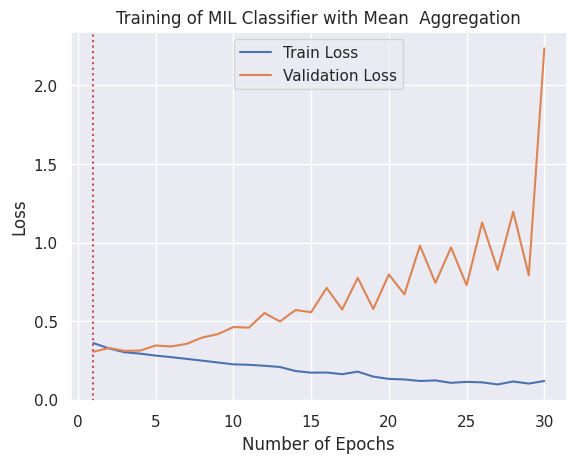

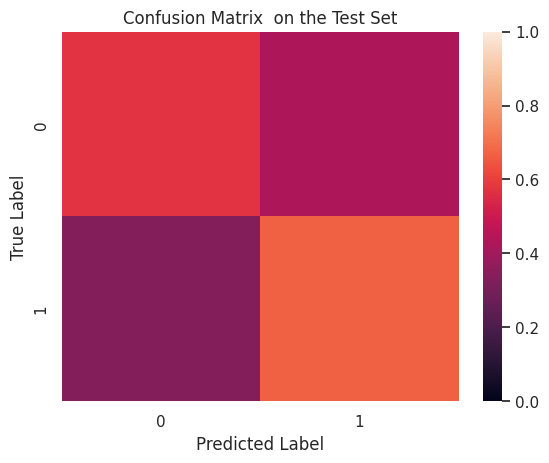

In [5]:
if use_sparse_data:
    run_params = RunParams(
        aggregator="MeanAggergation",
        n_hidden=3,
        hidden_size=10,
        encoding_size=10,
        seed=37,
        lr=10**-2,
        decay=10**-2,
        sparse=use_sparse_data,
        num_epochs=NUM_EPOCHS
    )
else:
    run_params = RunParams(
        aggregator="MeanAggergation",
        n_hidden=1,
        hidden_size=30,
        seed=27,
        encoding_size=30,
        lr=10**-2,
        decay=10**-1.7005985187830885,
        sparse=use_sparse_data,
        num_epochs=NUM_EPOCHS
    )

set_seed(run_params.seed)
encoder = MLP_encoder(
    n_hidden=run_params.n_hidden,
    hidden_size=run_params.hidden_size,
    output_size=run_params.encoding_size,
    input_size=INPUT_SIZE
)
aggregator = getattr(models, run_params.aggregator)(encoding_size=run_params.encoding_size)
run_evaluation(
    encoder,
    aggregator,
    run_params.lr,
    run_params.decay,
    plot_title="Training of MIL Classifier with Mean  Aggregation",
    run_params=run_params.model_dump(),
    path_prefix=str(PROJECT_ROOT / "data/torch_playground_mean_aggregation_models/epoch_")
)


## Maximum aggregation

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Min valid loss: Epoch 5, 0.2796


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train accuracy,▂▂▁▃▅▄▄▅▆▆▆▆▆▇▇▇▇▇██▇██▇▇████▇
train blanced accuracy,▁▁▁▁▄▄▃▅▆▆▆▆▆▇▇▇▇▇██▇██▇▇████▇
train f1,▂▂▁▁▅▅▄▅▆▆▆▇▇▇▇▇▇▇██▇██▇██████
train loss,▇▇█▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▁▂▂▁▁▁▁▁
train precision,▁▁▂▅▄▄▅▅▆▆▆▆▆▇▇▇▇▇██▇██▇▇████▇
train recall,▁▁▁▁▄▄▃▅▆▆▆▆▆▇▇▇▇▇██▇██▇▇████▇
val balanced accuracy,▁▂▁▂█▂▂▂▄▂▃▃▄▄▄▄▃▄▄▄▄▄▄▄▄▄▄▄▄▄
val f1,▁▂▁▂█▂▄▄▅▄▄▄▅▅▅▅▄▅▅▅▅▅▅▅▅▅▅▅▅▅
val precision,▁▇▁▇█▇▅▅█▅▆▆▆▆▆▆▅▆▆▆▆▆▆▆▆▆▆▆▆▆
+3,...


{'encoder': 'MLP_enxoder', 'n_hidden': 1, 'hidden_size': 30, 'input_size': 30, 'aggregator': 'MaxAggregation', 'encoding_size': 30}

Accuracy: 63.64%
Balanced Accuracy: 65.71%
Precision: 63.64%
Recall: 65.71%


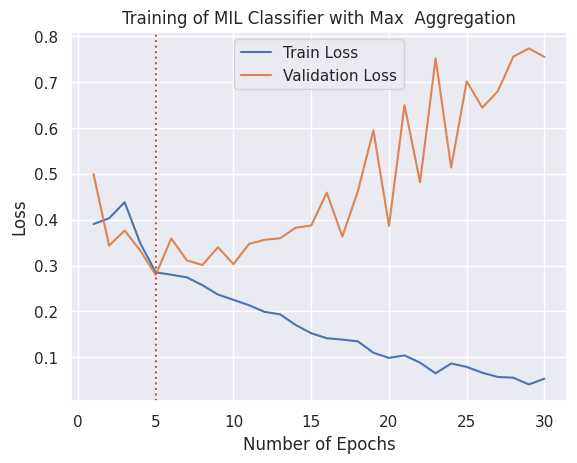

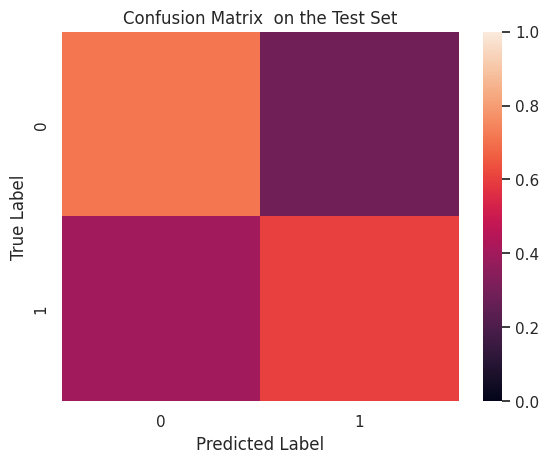

In [6]:
if use_sparse_data:
    run_params = RunParams(
        aggregator="MaxAggergation",
        n_hidden=3,
        hidden_size=10,
        encoding_size=10,
        seed=37,
        lr=10**-2,
        decay=10**-2,
        sparse=use_sparse_data,
        num_epochs=NUM_EPOCHS
    )
else:
    run_params = RunParams(
        aggregator="MaxAggergation",
        n_hidden=1,
        hidden_size=30,
        seed=27,
        encoding_size=30,
        lr=10**-2,
        decay=10**-1.7005985187830885,
        sparse=use_sparse_data,
        num_epochs=NUM_EPOCHS
    )

set_seed(run_params.seed)
encoder = MLP_encoder(
    n_hidden=run_params.n_hidden,
    hidden_size=run_params.hidden_size,
    output_size=run_params.encoding_size,
    input_size=INPUT_SIZE
)
aggregator = getattr(models, run_params.aggregator)(encoding_size=run_params.encoding_size)
run_evaluation(
    encoder,
    aggregator,
    run_params.lr,
    run_params.decay,
    plot_title="Training of MIL Classifier with Max  Aggregation",
    run_params=run_params.model_dump(),
    path_prefix=str(PROJECT_ROOT / "data/torch_playground_max_aggregation_models/epoch_")
)


## Attention Aggregation

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Min valid loss: Epoch 4, 0.3053


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train accuracy,▁▁▃▃▄▄▄▅▅▅▅▆▅▇▆▆▇▆▇▇▇▇▇████▇▇▇
train blanced accuracy,▁▂▂▃▄▄▄▅▅▅▅▆▅▇▆▆▇▆▇▇▇▇▇████▇▇▇
train f1,▁▂▂▃▄▄▄▅▅▅▅▆▆▇▆▇▇▇▇█▇▇▇█████▇▇
train loss,█▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▂▂▂
train precision,▁▃▃▃▄▄▅▅▅▅▅▆▆▇▆▇▇▆▇▇▇▇▇█████▇▇
train recall,▁▂▂▃▄▄▄▅▅▅▅▆▅▇▆▆▇▆▇▇▇▇▇████▇▇▇
val balanced accuracy,▁▄▅▇▆▆▅█▇▆▆▄▅▄▅▆▆▆▅▅▇▆▆▆▆▆▆▅▇▄
val f1,▁▃▅▇▆▆▅█▇▆▇▃▅▅▅▆▆▆▆▆▇▆▆▆▆▆▆▆▇▃
val precision,▁▇█▇███▇█▇▆▇▆▅▆███▆▆█▇▇▇▇▇▇▅▇▇
+3,...


{'encoder': 'MLP_enxoder', 'n_hidden': 3, 'hidden_size': 40, 'input_size': 30, 'aggregator': 'AttentionAggregation', 'encoding_size': 40, 'attention_hidden_size': 10}

Accuracy: 77.27%
Balanced Accuracy: 71.90%
Precision: 73.96%
Recall: 71.90%


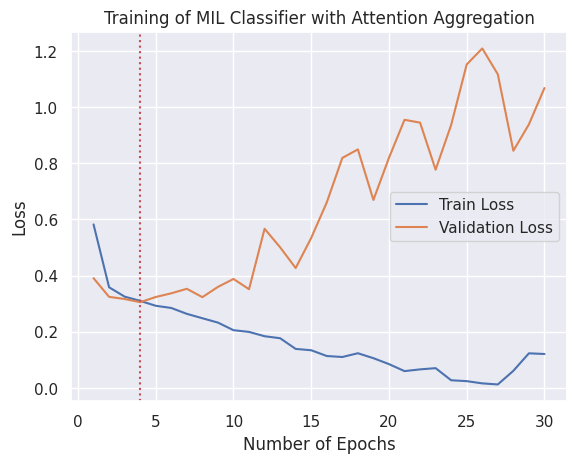

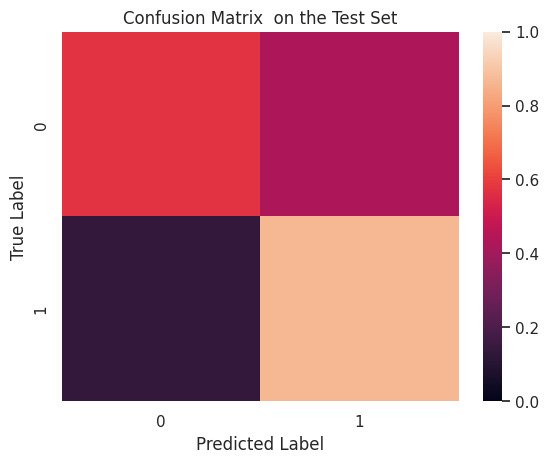

In [7]:
if use_sparse_data:
    run_params = RunParams(
        aggregator="AttentionAggregation",
        encoding_size=10,
        attention_hidden_size=10,
        hidden_size=10,
        n_hidden=3,
        seed=2023,
        lr=10**-3,
        decay=10**-2,
        sparse=use_sparse_data,
        num_epochs=NUM_EPOCHS
    )
else:
    run_params = RunParams(
        aggregator="AttentionAggregation",
        encoding_size=40,
        attention_hidden_size=10,
        hidden_size=40,
        n_hidden=3,
        seed=42,
        lr=10**-2,
        decay=10**-2,
        sparse=use_sparse_data,
        num_epochs=NUM_EPOCHS
    )

set_seed(run_params.seed)
encoder = MLP_encoder(
    n_hidden=run_params.n_hidden,
    hidden_size=run_params.hidden_size,
    output_size=run_params.encoding_size,
    input_size=INPUT_SIZE
)
aggregator = getattr(models, run_params.aggregator)(encoding_size=run_params.encoding_size, attention_hidden_size=run_params.attention_hidden_size)
run_evaluation(
    encoder,
    aggregator,
    run_params.lr,
    run_params.decay,
    plot_title="Training of MIL Classifier with Attention Aggregation",
    run_params=run_params.model_dump(),
    path_prefix=str(PROJECT_ROOT / "data/torch_playground_attentionaggregation_models/epoch_")
)


## Gated Attention Aggregation

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Min valid loss: Epoch 4, 0.3236


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train accuracy,▁▂▂▃▄▅▅▅▅▆▆▆▇▆▇▇▇▇▇▇▇██▇███▇██
train blanced accuracy,▁▂▂▃▄▅▅▅▅▆▆▆▇▆▇▆▇▇▇▇▇██▇███▇██
train f1,▁▂▂▃▄▅▅▅▅▆▆▆▇▆▇▇▇▇▇▇▇██▇███▇██
train loss,█▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▂▁▁▁▁▁▁
train precision,▁▂▃▃▄▅▅▆▅▆▇▆▇▆▇▇▇▇▇▇▇██▇███▇██
train recall,▁▂▂▃▄▅▅▅▅▆▆▆▇▆▇▆▇▇▇▇▇██▇███▇██
val balanced accuracy,▆███▃█▄▃▄▃▄▁▄▄▄▄▄▄▆▆▄▄▄▆▄▆▄▆▆▆
val f1,▇███▃█▅▃▅▃▅▁▅▅▅▅▅▅▆▆▅▅▅▆▅▆▅▆▆▆
val precision,▅███▄█▆▄▆▄▄▁▆▆▆▄▆▆▇▇▆▆▄▇▆▇▄▇▇▇
+3,...


{'encoder': 'MLP_enxoder', 'n_hidden': 2, 'hidden_size': 43, 'input_size': 30, 'aggregator': 'GatedAttentionAggregation', 'encoding_size': 4, 'attention_hidden_size': 42}

Accuracy: 77.27%
Balanced Accuracy: 71.90%
Precision: 73.96%
Recall: 71.90%


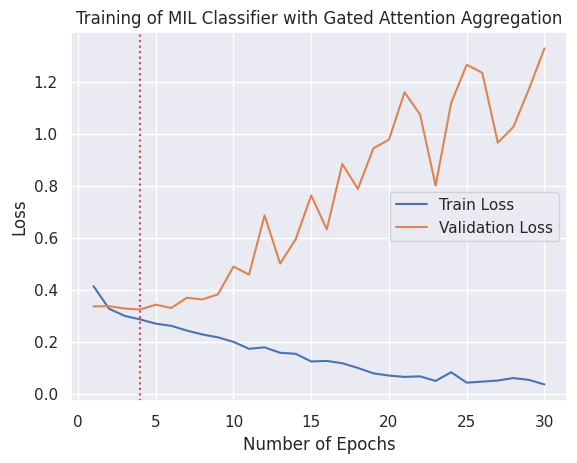

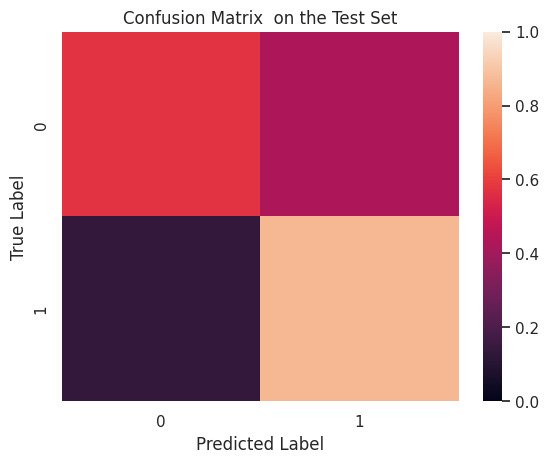

In [8]:
run_params = RunParams(
    aggregator="GatedAttentionAggregation",
    encoding_size=4,
    attention_hidden_size=42,
    hidden_size=43,
    n_hidden=2,
    seed=42,
    lr=10**-2,
    decay=10**-2,
    sparse=use_sparse_data,
    num_epochs=NUM_EPOCHS
)

set_seed(run_params.seed)
encoder = MLP_encoder(
    n_hidden=run_params.n_hidden,
    hidden_size=run_params.hidden_size,
    output_size=run_params.encoding_size,
    input_size=INPUT_SIZE
)
aggregator = getattr(models, run_params.aggregator)(encoding_size=run_params.encoding_size, attention_hidden_size=run_params.attention_hidden_size)
run_evaluation(
    encoder,
    aggregator,
    run_params.lr,
    run_params.decay,
    plot_title="Training of MIL Classifier with Gated Attention Aggregation",
    run_params=run_params.model_dump(),
    path_prefix=str(PROJECT_ROOT / "data/trorch_playground_gated_attention_aggregation_models/epoch_")
)
